In [1]:
import pandas as pd

import mysql.connector
from config import DB_CONFIG

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
conn = mysql.connector.connect(**DB_CONFIG)

if conn.is_connected():
    print("Database Connected Successfully!")

Database Connected Successfully!


In [3]:
df = pd.read_sql('select * from ecommerce_cleaned', con = conn)
conn.close()

C:\Users\Ekamjot Singh\AppData\Local\Temp\ipykernel_24740\3627570471.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('select * from ecommerce_cleaned', con = conn)


In [4]:
print("rows :", df.shape[0],"\ncolumns :",df.shape[1])
print(df.dtypes)

rows : 5628 
columns : 20
CustomerID                       int64
Churn                            int64
Tenure                           int64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                  int64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                   int64
NumberOfDeviceRegistered         int64
PreferredOrderCat               object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear      int64
CouponUsed                       int64
OrderCount                       int64
DaySinceLastOrder                int64
CashbackAmount                 float64
dtype: object


In [5]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferredOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4,Mobile Phone,3,6,Debit Card,Female,3,3,Laptop & Accessory,2,Single,9,1,11,1,1,5,159.93
1,50002,1,1,Mobile Phone,1,8,UPI,Male,3,4,Mobile Phone,3,Single,7,1,15,0,1,0,120.90
2,50003,1,1,Mobile Phone,1,30,Debit Card,Male,2,4,Mobile Phone,3,Single,6,1,14,0,1,3,120.28
3,50004,1,0,Mobile Phone,3,15,Debit Card,Male,2,4,Laptop & Accessory,5,Single,8,0,23,0,1,3,134.07
4,50005,1,0,Mobile Phone,1,12,Credit Card,Male,3,3,Mobile Phone,5,Single,3,0,11,1,1,3,129.60


In [6]:
df['Churn'] = df['Churn'].astype(bool)
df['Complain'] = df['Complain'].astype(bool)

In [7]:
categorical_cols = ['PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode', 'Gender',
                     'NumberOfDeviceRegistered', 'PreferredOrderCat', 'SatisfactionScore',
                     'MaritalStatus']

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [8]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferredOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,True,4,Mobile Phone,3,6,Debit Card,Female,3,3,Laptop & Accessory,2,Single,9,True,11,1,1,5,159.93
1,50002,True,1,Mobile Phone,1,8,UPI,Male,3,4,Mobile Phone,3,Single,7,True,15,0,1,0,120.90
2,50003,True,1,Mobile Phone,1,30,Debit Card,Male,2,4,Mobile Phone,3,Single,6,True,14,0,1,3,120.28
3,50004,True,0,Mobile Phone,3,15,Debit Card,Male,2,4,Laptop & Accessory,5,Single,8,False,23,0,1,3,134.07
4,50005,True,0,Mobile Phone,1,12,Credit Card,Male,3,3,Mobile Phone,5,Single,3,False,11,1,1,3,129.60


In [9]:
df.dtypes

CustomerID                        int64
Churn                              bool
Tenure                            int64
PreferredLoginDevice           category
CityTier                       category
WarehouseToHome                   int64
PreferredPaymentMode           category
Gender                         category
HourSpendOnApp                    int64
NumberOfDeviceRegistered       category
PreferredOrderCat              category
SatisfactionScore              category
MaritalStatus                  category
NumberOfAddress                   int64
Complain                           bool
OrderAmountHikeFromlastYear       int64
CouponUsed                        int64
OrderCount                        int64
DaySinceLastOrder                 int64
CashbackAmount                  float64
dtype: object

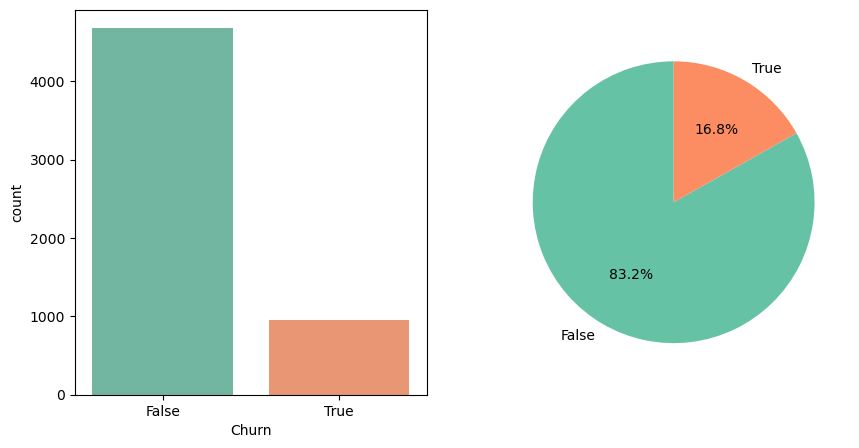

In [16]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
sns.countplot(data = df, x = "Churn", hue = "Churn", palette = "Set2", legend = False)
plt.subplot(1,2,2)
plt.pie(churn_counts,labels = churn_counts.index, autopct = "%1.1f%%", colors = sns.color_palette("Set2"), startangle = 90)
plt.savefig('../eda/univariate_target_churn.png', dpi=300, bbox_inches='tight')
plt.show()

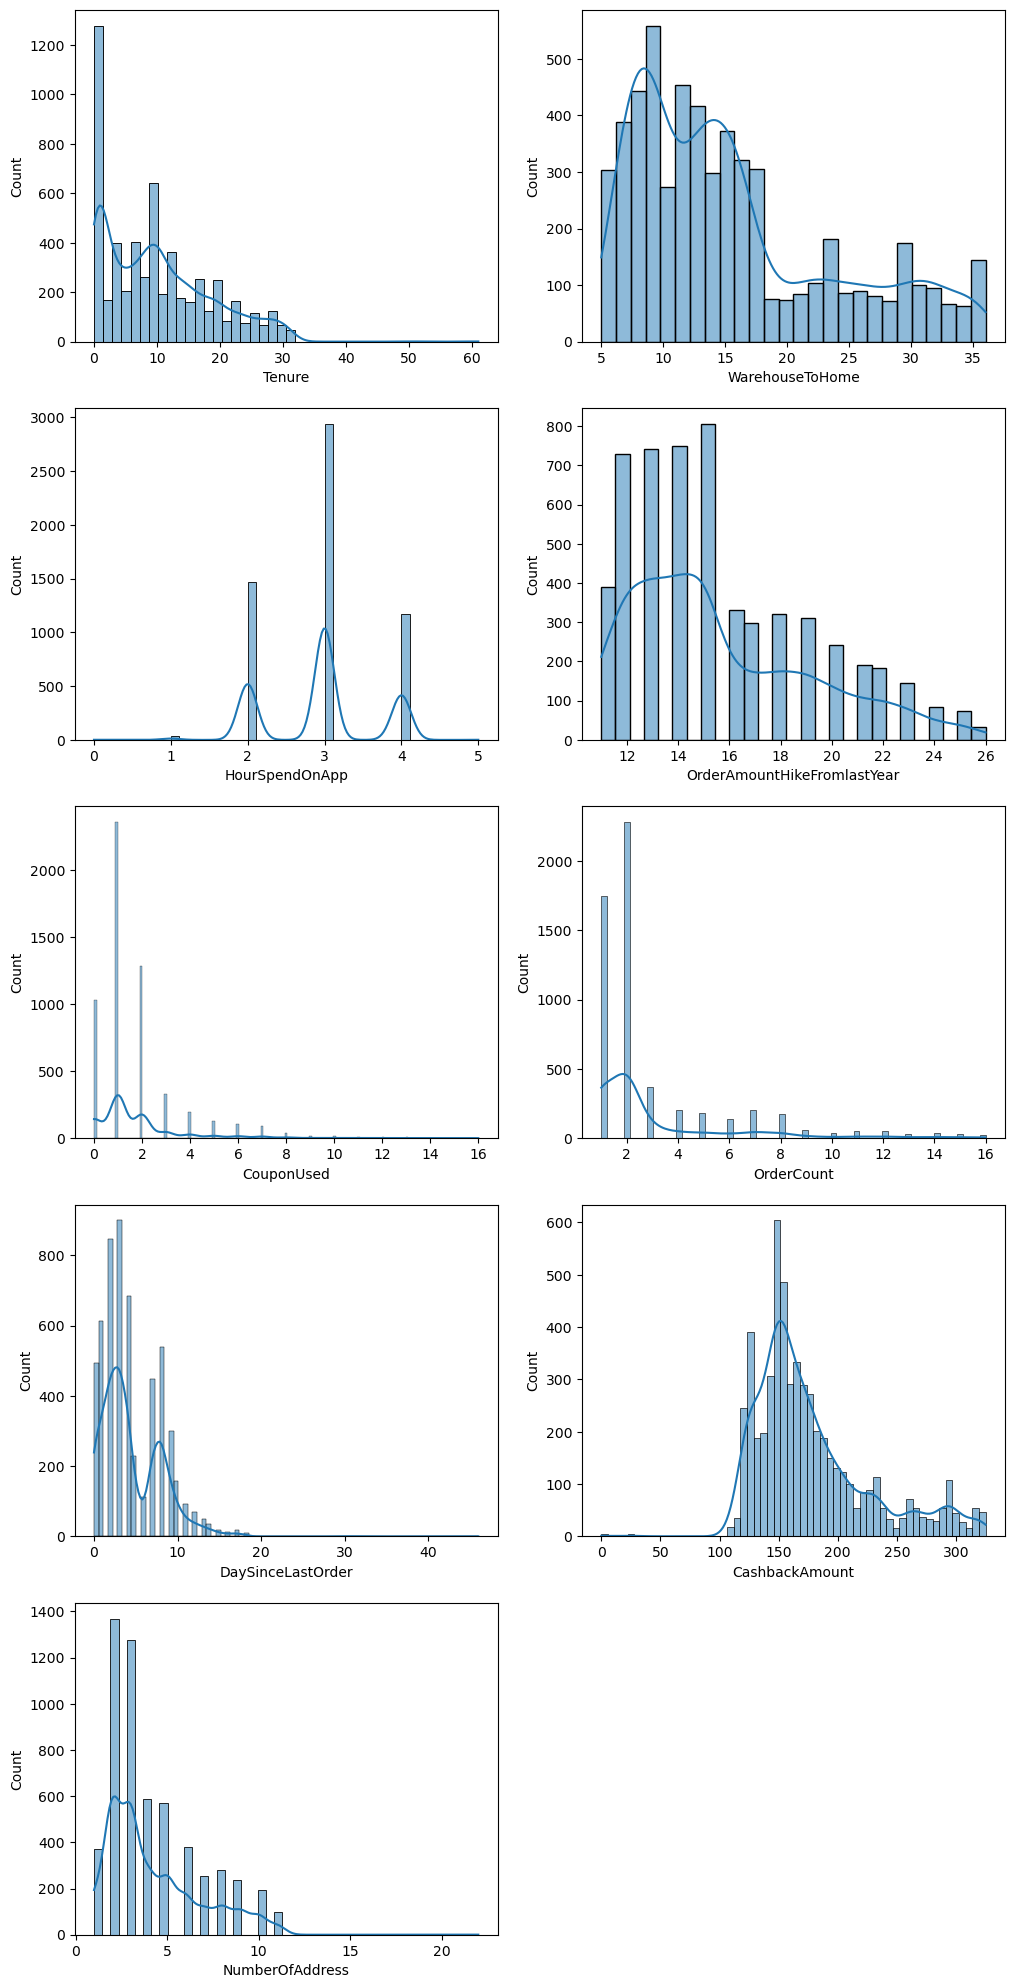

Tenure : 9.0
WarehouseToHome : 13.0
HourSpendOnApp : 3.0
OrderAmountHikeFromlastYear : 15.0
CouponUsed : 1.0
OrderCount : 2.0
DaySinceLastOrder : 3.0
CashbackAmount : 163.33
NumberOfAddress : 3.0


In [17]:
numerical_columns = ["Tenure", "WarehouseToHome", "HourSpendOnApp", "OrderAmountHikeFromlastYear", "CouponUsed", "OrderCount", "DaySinceLastOrder", "CashbackAmount", "NumberOfAddress"]

plt.figure(figsize = (12,25))

for i, numerical_column in enumerate(numerical_columns):
    plt.subplot(5,2,i+1)
    sns.histplot(df[numerical_column], kde = True)
    
plt.savefig('../eda/univariate_numerical_plots.png', dpi=300, bbox_inches='tight')
plt.show()

for numerical_column in numerical_columns:
    print(f"{numerical_column} : {df[numerical_column].median()}")

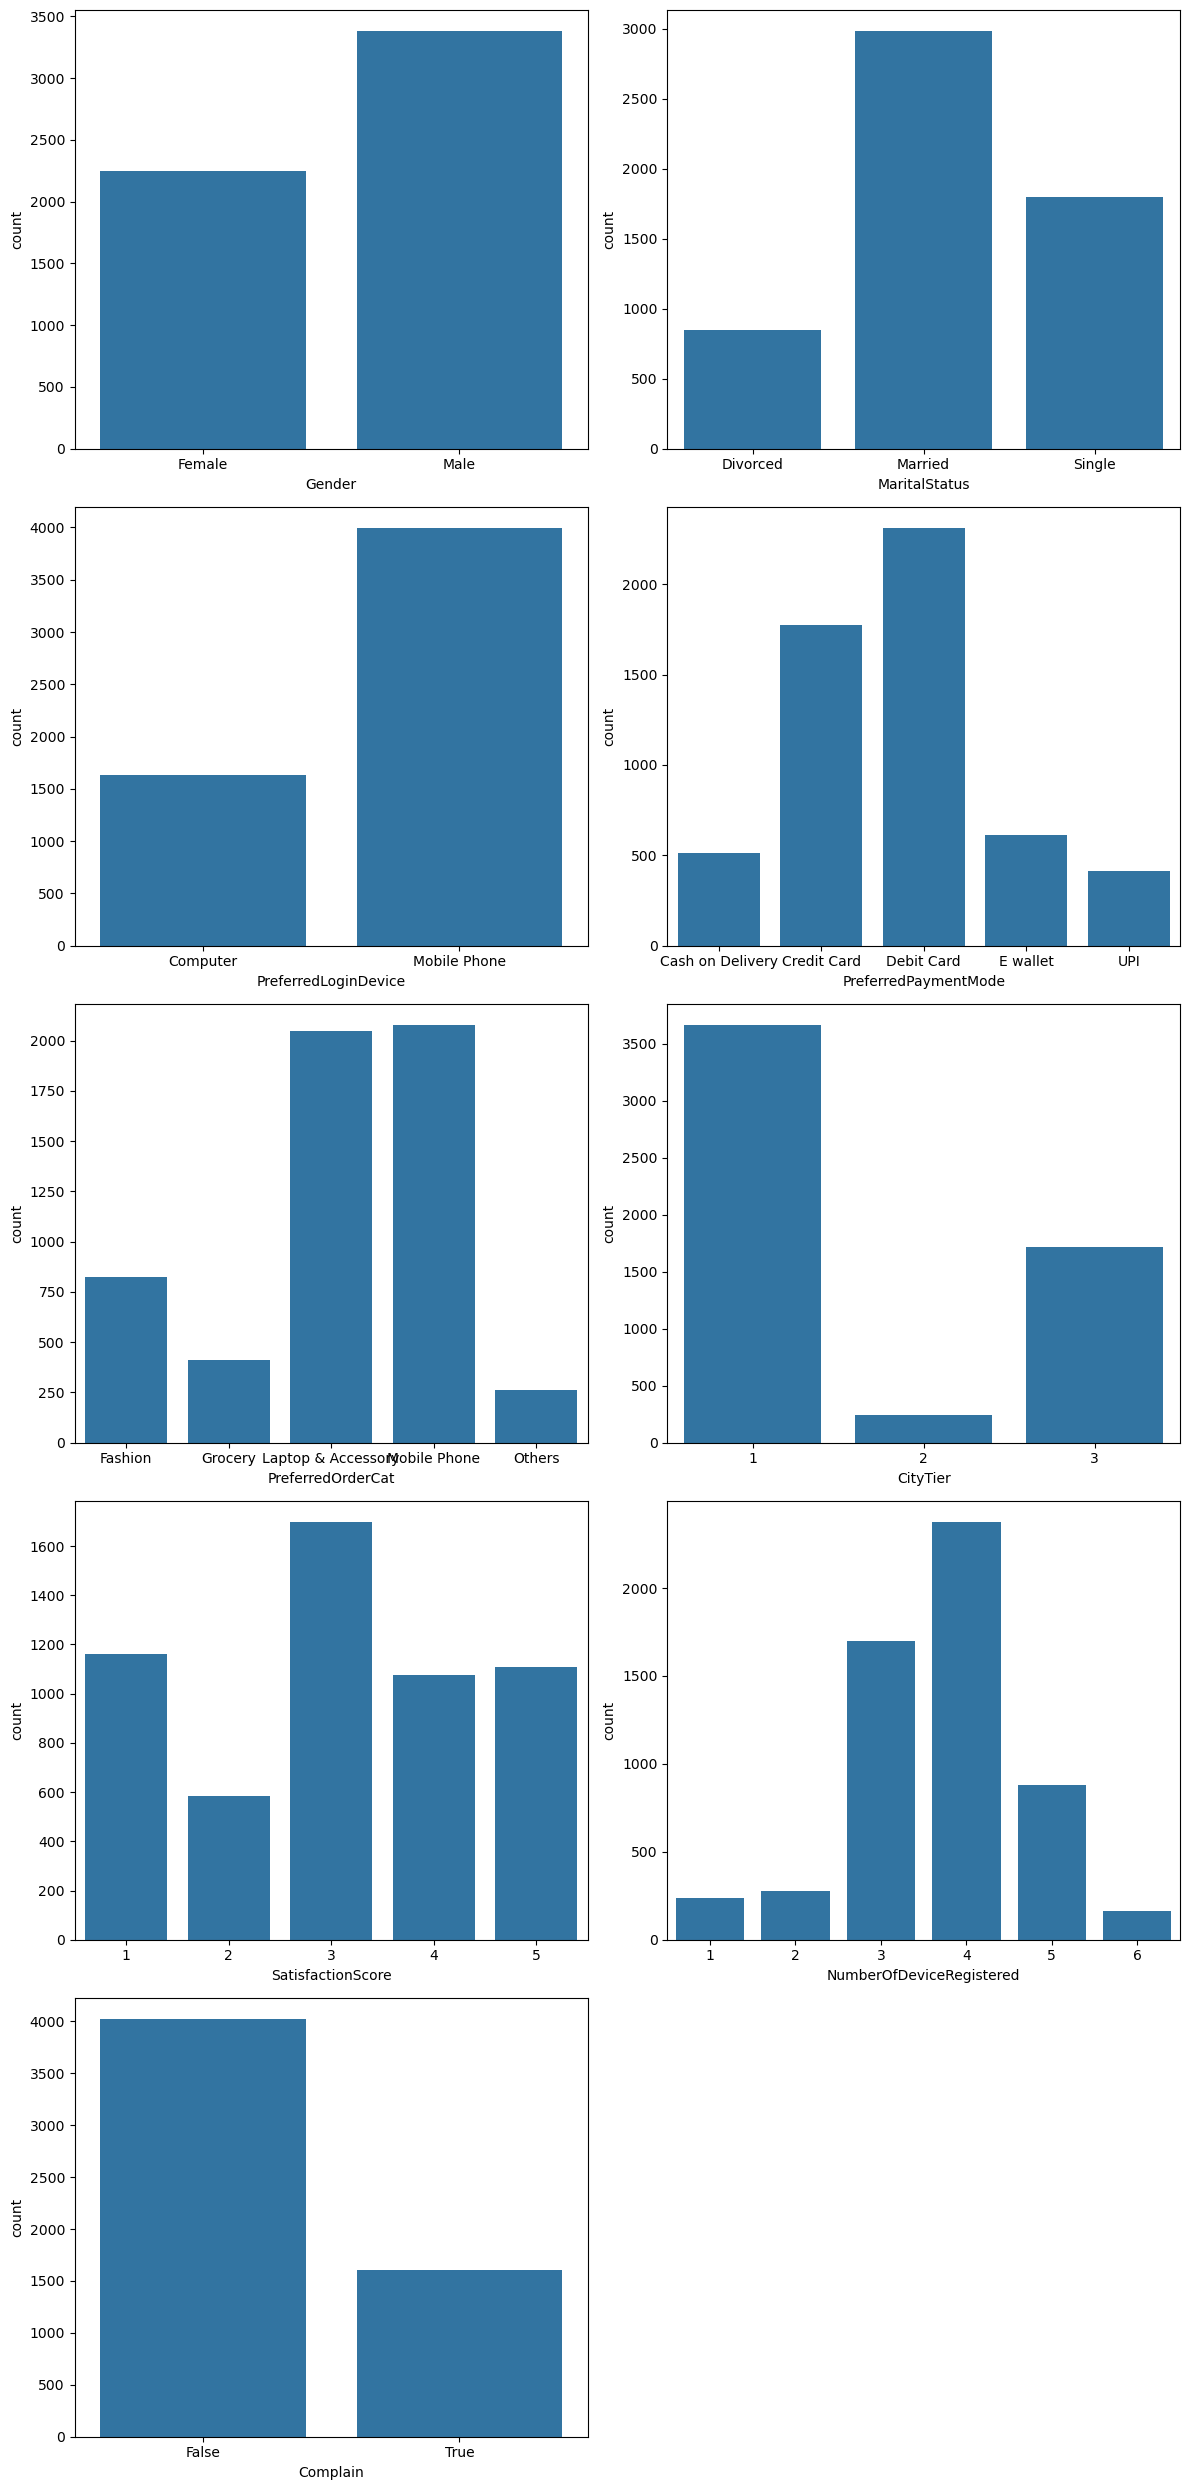

In [12]:
categorical_columns = ["Gender", "MaritalStatus", "PreferredLoginDevice", "PreferredPaymentMode", "PreferredOrderCat", "CityTier", "SatisfactionScore", "NumberOfDeviceRegistered", "Complain"]

plt.figure(figsize = (12,25))

for i, categorical_column in enumerate(categorical_columns):
    plt.subplot(5,2,i+1)
    sns.countplot(data = df, x = categorical_column)
    plt.tight_layout()

plt.savefig('../eda/univariate_categorical_col_plots.png', dpi=300, bbox_inches='tight')
plt.show()

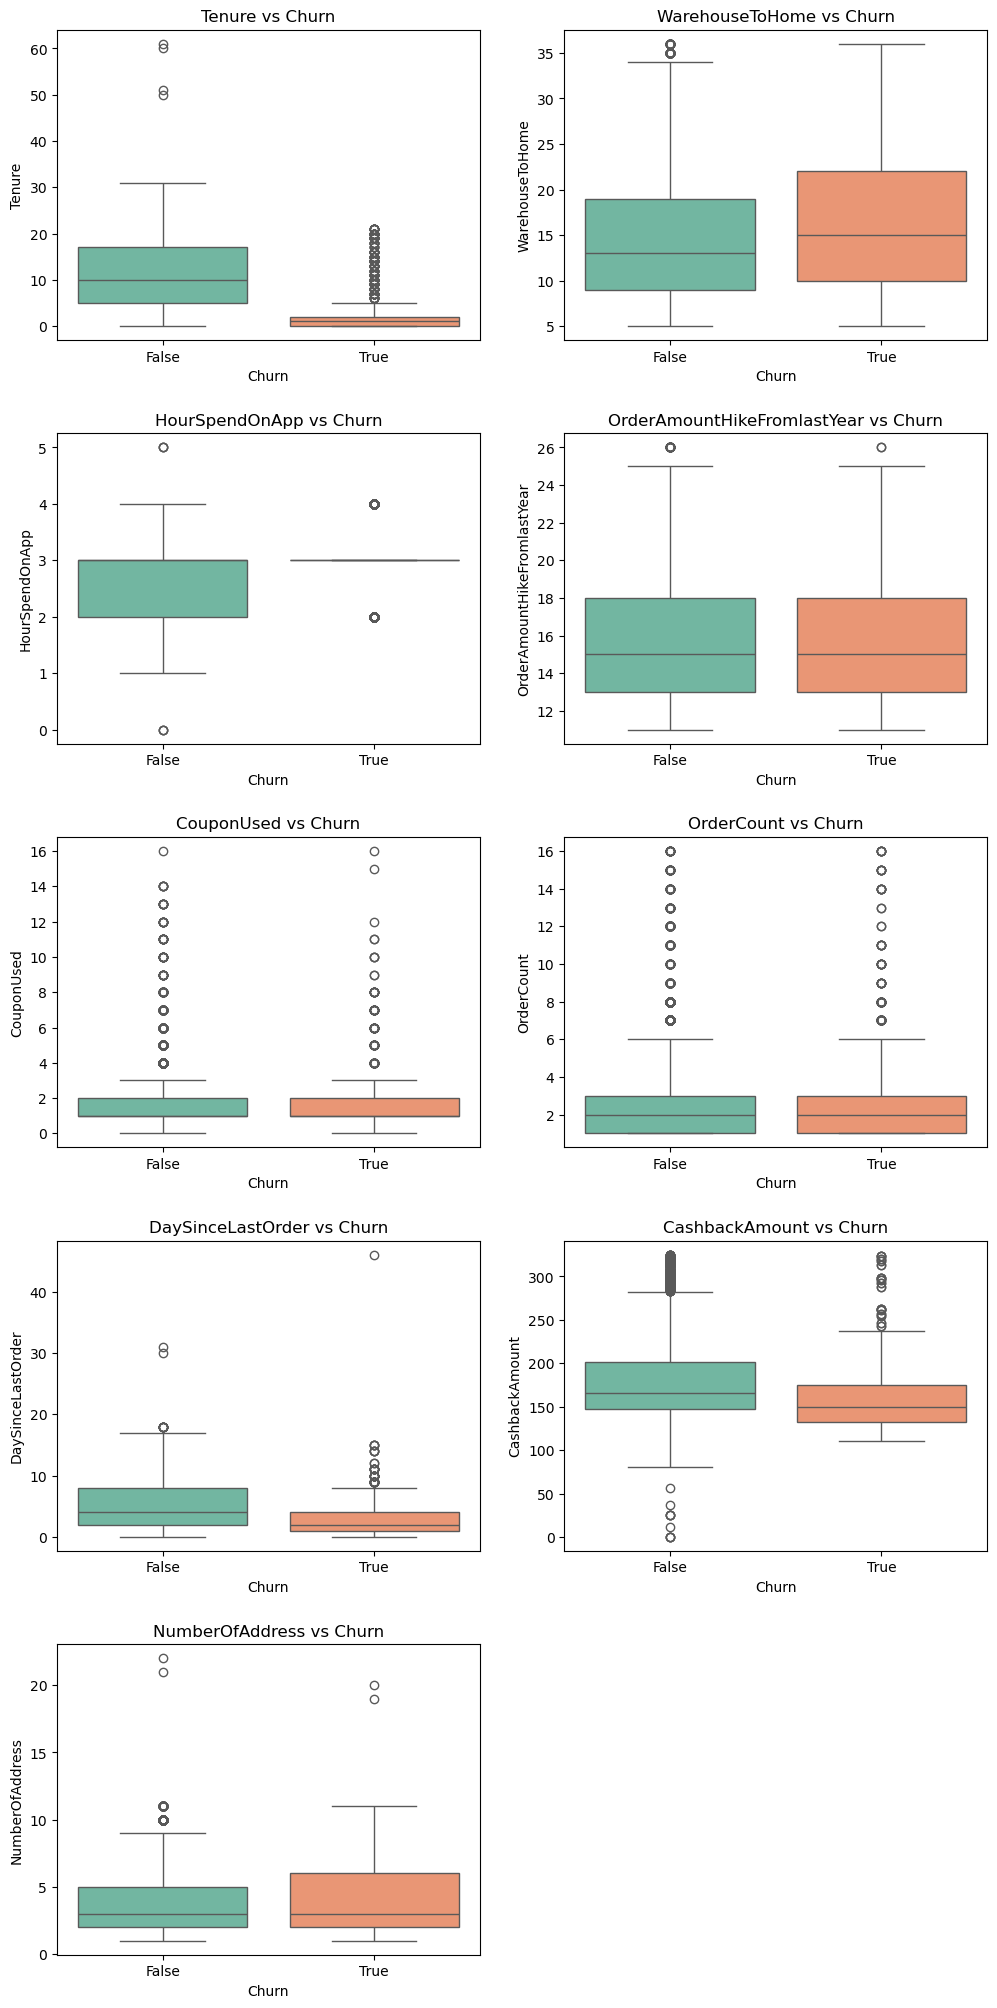

In [13]:
fig, axes = plt.subplots(5,2, figsize = (12,25),gridspec_kw={'hspace': 0.3})
axes = axes.flatten()

for i, numerical_column in enumerate(numerical_columns):
    sns.boxplot(data = df, x = "Churn", y = numerical_column , hue = "Churn", palette = "Set2", legend = False, ax = axes[i])
    axes[i].set_title(f"{numerical_column} vs Churn")

axes[-1].axis('off')
plt.savefig('../eda/numeric_vs_churn_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

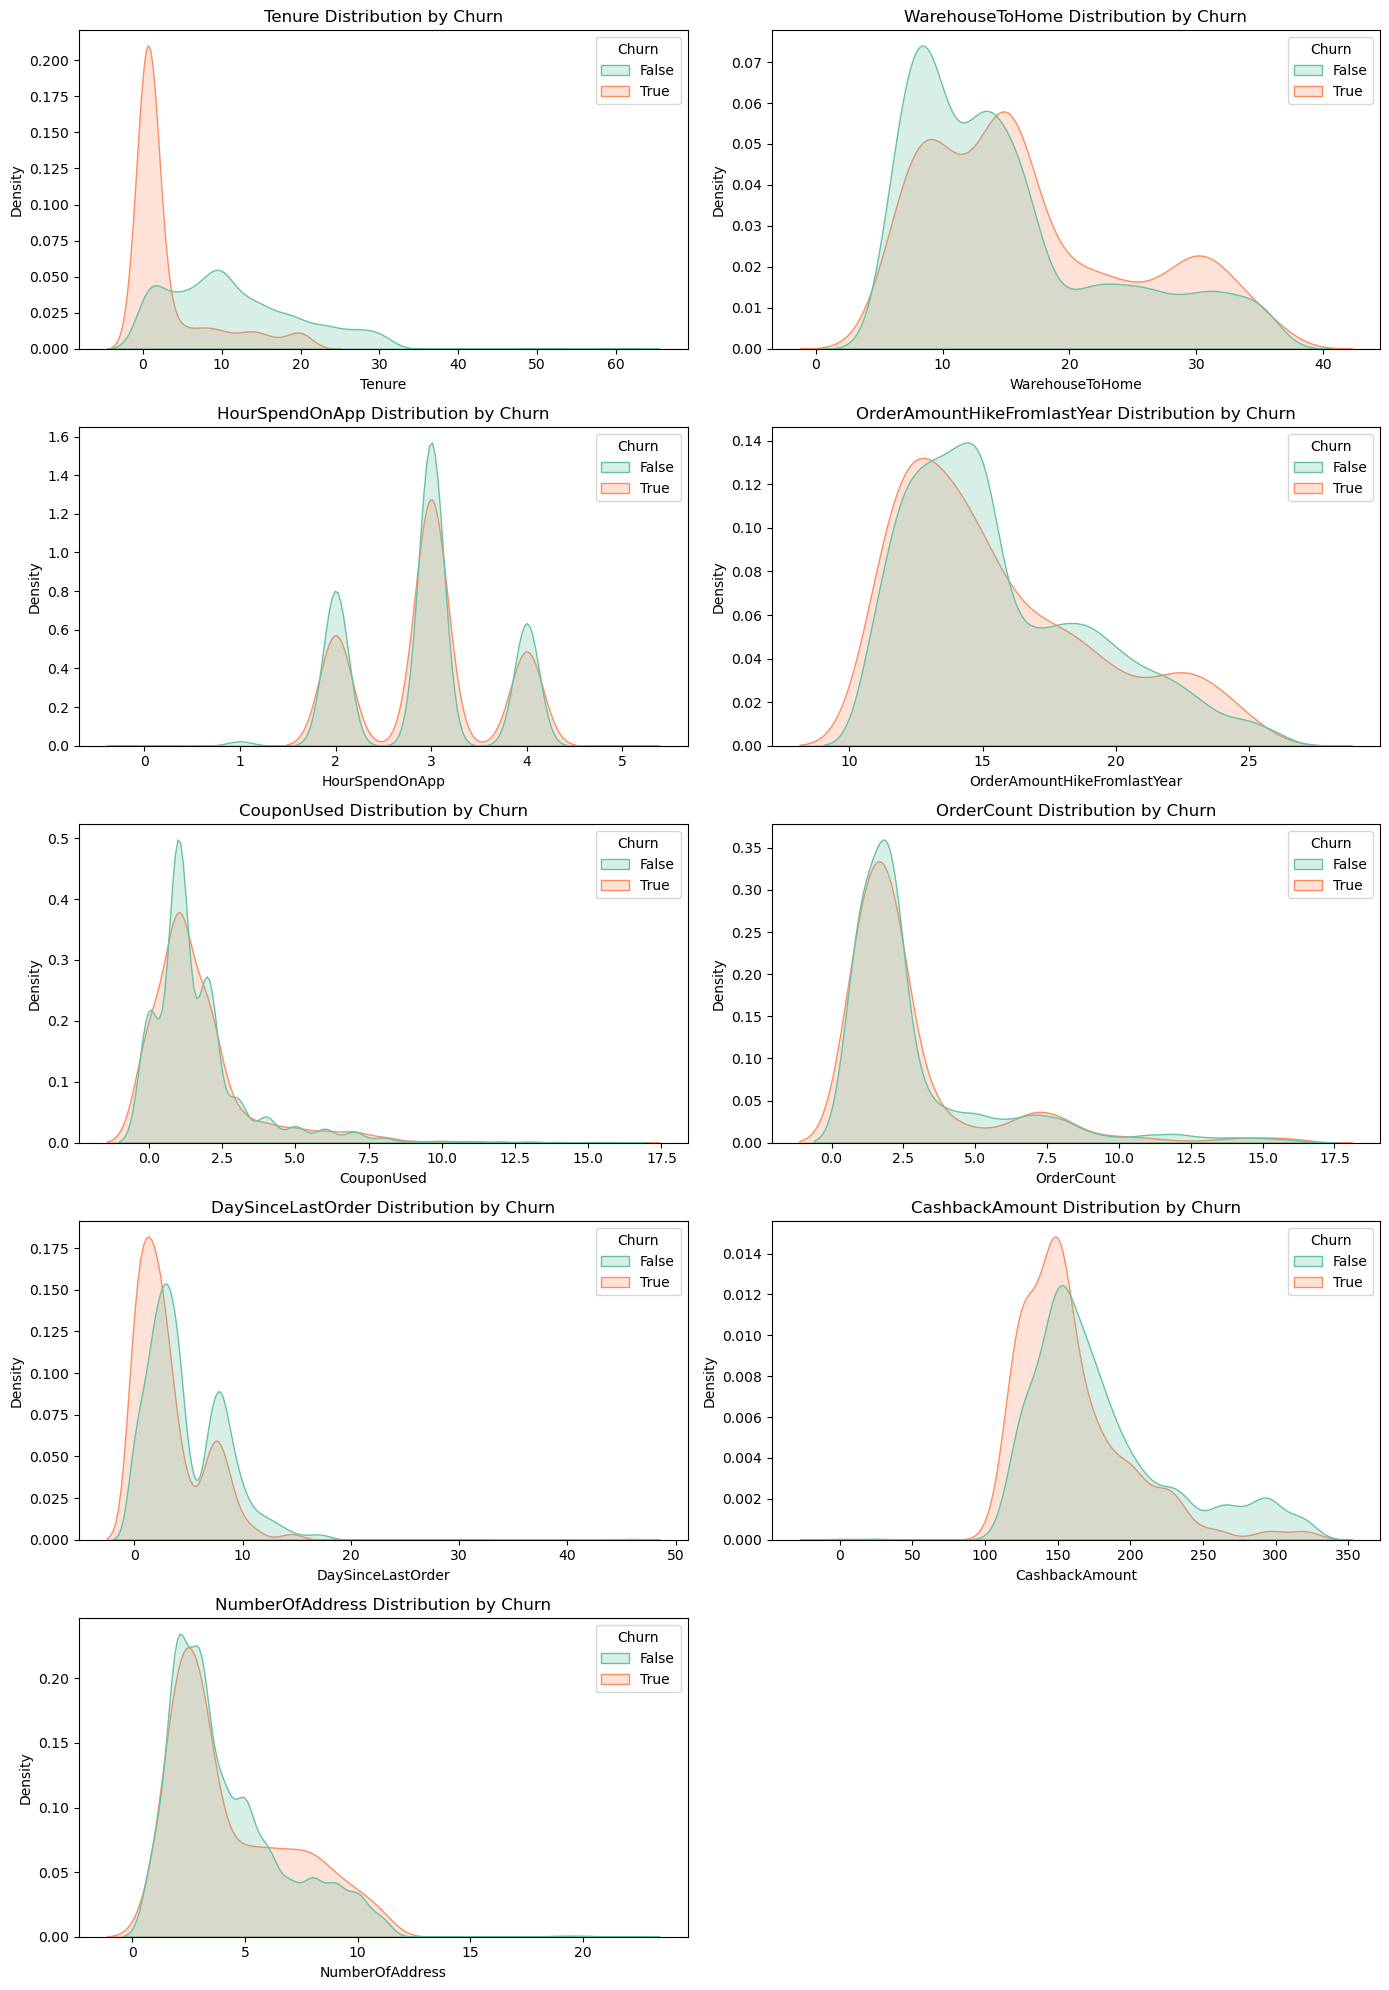

In [14]:
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} Distribution by Churn')

axes[-1].axis('off')

plt.tight_layout()
plt.savefig('../eda/numeric_vs_churn_kdeplots.png', dpi=300, bbox_inches='tight')
plt.show()

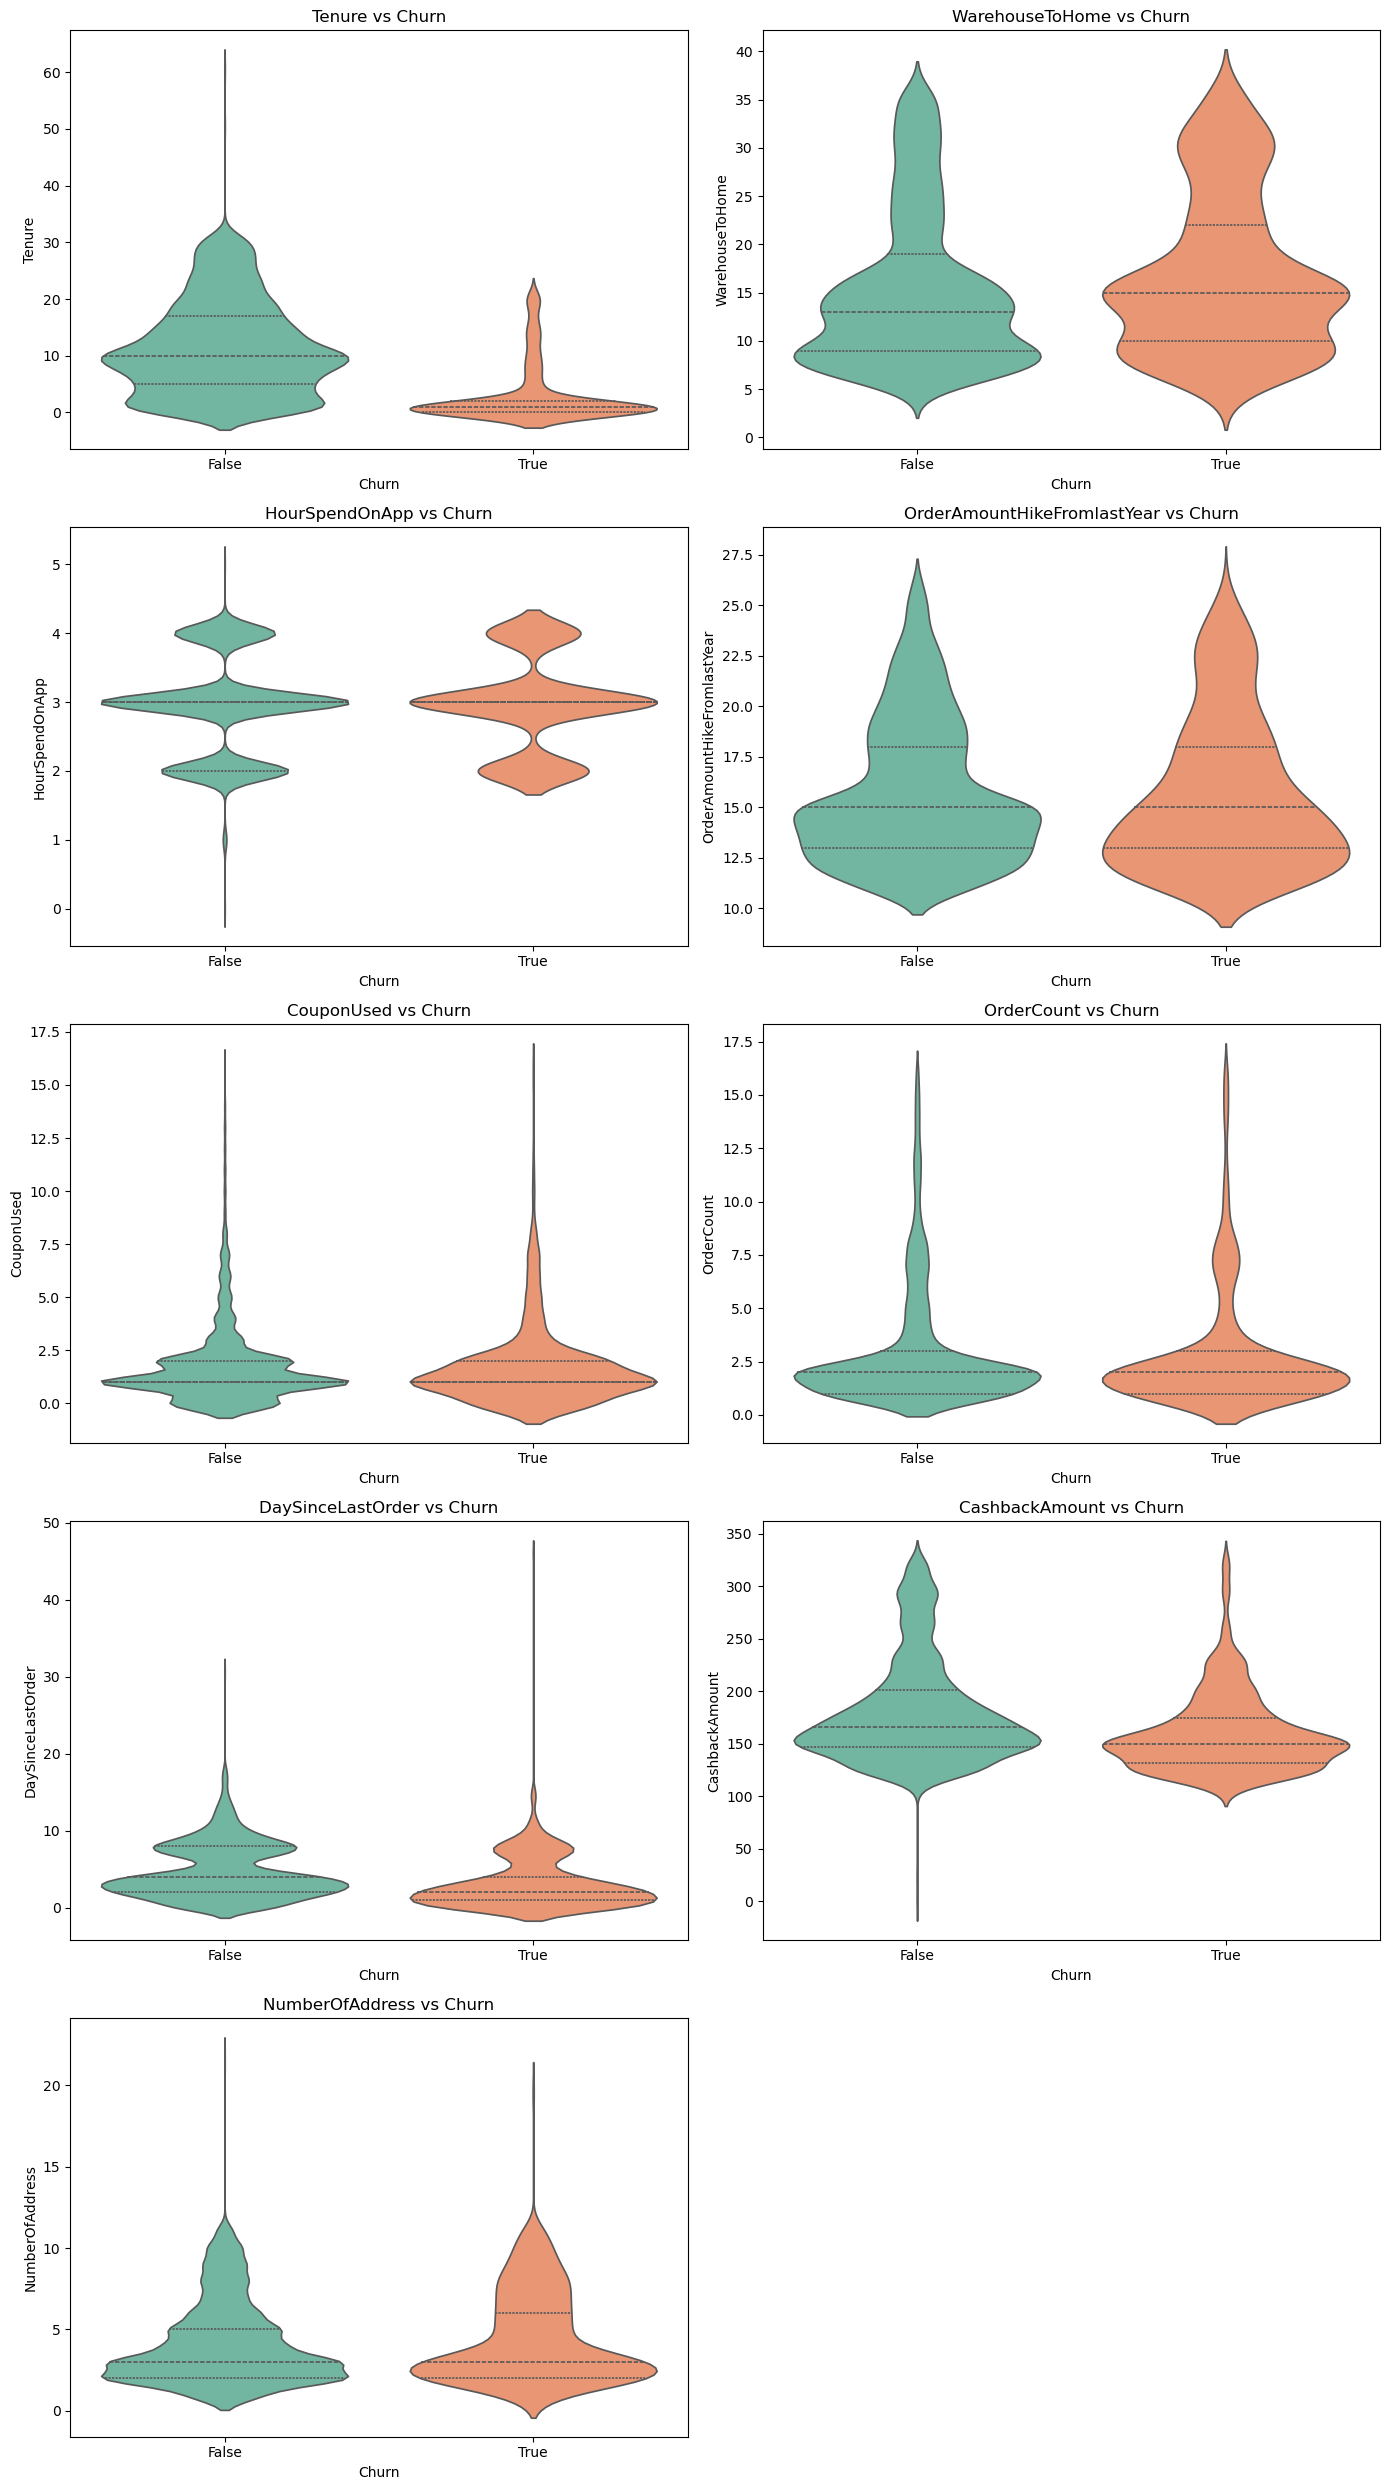

In [15]:
fig, axes = plt.subplots(5, 2, figsize=(14, 25))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.violinplot(data=df, x='Churn', y=col, hue='Churn', palette='Set2', legend=False, inner= "quartile", ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')
    axes[i].set_xlabel('Churn')
    axes[i].set_ylabel(col)

axes[-1].axis('off')

plt.tight_layout()
plt.savefig('../eda/numeric_vs_churn_violinplots.png', dpi=300, bbox_inches='tight')
plt.show()